# Steam 인디게임 초기 반응 분석

## 분석 목적
- 출시 후 30일 기준 초기 리뷰 반응 규모 확인
- 초기 긍정률 및 Wilson score 기반 품질 지표 생성
- 초기 반응이 이후 리뷰 유입으로 이어지는지 확인
- 게임별 반응 유형 분류
- 최종 분석용 CSV 저장



# 0. 라이브러리 호출

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu, kruskal
from IPython.display import display
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)


# 1. 데이터 호출

In [43]:
# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정합니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# 원천/소스 파일이 들어있는 폴더
print("호출 폴더")
DATA_DIR = ROOT / "data" / "processed"
FULL_PATH = DATA_DIR / "steam_indie_review_histogram_preprocessed_lee_v1.csv"

print("DATA_DIR:", DATA_DIR)
print("FULL_PATH:", FULL_PATH)

main_df = pd.read_csv(FULL_PATH)
df = main_df.copy()

print("데이터 크기:", df.shape)
display(df.head())

호출 폴더
DATA_DIR: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\processed
FULL_PATH: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\processed\steam_indie_review_histogram_preprocessed_lee_v1.csv
데이터 크기: (11782, 15)


,appid,name,stratum,release_date,hist_start_date,hist_end_date,date,recommendations_up,recommendations_down,data_type,review_date,recommendations_total,days_from_release,release_period,histogram_key
0,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-07,0,0,recent,2026-03-07,0,556,D181_plus,402160_2026-03-07_recent
1,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-08,0,0,recent,2026-03-08,0,557,D181_plus,402160_2026-03-08_recent
2,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-09,0,0,recent,2026-03-09,0,558,D181_plus,402160_2026-03-09_recent
3,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-10,0,0,recent,2026-03-10,0,559,D181_plus,402160_2026-03-10_recent
4,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-11,0,0,recent,2026-03-11,0,560,D181_plus,402160_2026-03-11_recent


# 간단 점검

In [44]:
def check_basic_info(df, df_name, exclude_cols=None):
    """행/열 수, 완전 중복 행, 컬럼별 타입/결측/고유값을 한 번에 확인"""
    print(f"\n{'='*80}")
    print(f"{df_name}의 기본 정보 / 타입 / 결측치 확인")
    print(f"{'='*80}\n")

    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)

    # 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })

    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df_copied) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df_copied) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    }).sort_values(by=['결측치 개수', '고유값 개수'], ascending=[False, False])

    print("[전체 요약]")
    display(overview_df)

    print("[컬럼별 요약]")
    display(summary_df)

    print("[상위 5행]")
    display(df_copied.head())

In [45]:
check_basic_info(df, "df_hist")


df_hist의 기본 정보 / 타입 / 결측치 확인

[전체 요약]


,항목,값
0,행 개수,11782
1,열 개수,15
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
histogram_key,str,11782,100.0,0,0.0,11782
days_from_release,int64,11782,100.0,0,0.0,1904
date,str,11782,100.0,0,0.0,995
review_date,str,11782,100.0,0,0.0,995
recommendations_total,int64,11782,100.0,0,0.0,334
recommendations_up,int64,11782,100.0,0,0.0,321
appid,int64,11782,100.0,0,0.0,200
name,str,11782,100.0,0,0.0,200
release_date,str,11782,100.0,0,0.0,177
hist_start_date,str,11782,100.0,0,0.0,177


[상위 5행]


,appid,name,stratum,release_date,hist_start_date,hist_end_date,date,recommendations_up,recommendations_down,data_type,review_date,recommendations_total,days_from_release,release_period,histogram_key
0,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-07,0,0,recent,2026-03-07,0,556,D181_plus,402160_2026-03-07_recent
1,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-08,0,0,recent,2026-03-08,0,557,D181_plus,402160_2026-03-08_recent
2,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-09,0,0,recent,2026-03-09,0,558,D181_plus,402160_2026-03-09_recent
3,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-10,0,0,recent,2026-03-10,0,559,D181_plus,402160_2026-03-10_recent
4,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-11,0,0,recent,2026-03-11,0,560,D181_plus,402160_2026-03-11_recent


In [46]:
def check_steam_info(data, data_name="data"):
    """
    스팀 게임 데이터의 기본 구조를 빠르게 확인하는 함수
    """
    print("=" * 80)
    print(f"{data_name} 기본 정보")
    print("=" * 80)
    print("행/열:", data.shape)
    print("중복 행 수:", data.duplicated().sum())
    print("게임 수:", data["appid"].nunique() if "appid" in data.columns else "appid 없음")

    info = pd.DataFrame({
        "column": data.columns,
        "dtype": data.dtypes.astype(str).values,
        "missing_count": data.isna().sum().values,
        "missing_ratio": (data.isna().mean() * 100).round(2).values,
        "nunique": data.nunique(dropna=False).values
    })
    
    display(info)


check_basic_info(df, "review_histogram")

print("\ndata_type 분포")
display(df["data_type"].value_counts(dropna=False).reset_index())

print("\nrelease_period 분포")
display(df["release_period"].value_counts(dropna=False).reset_index())


review_histogram의 기본 정보 / 타입 / 결측치 확인

[전체 요약]


,항목,값
0,행 개수,11782
1,열 개수,15
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
histogram_key,str,11782,100.0,0,0.0,11782
days_from_release,int64,11782,100.0,0,0.0,1904
date,str,11782,100.0,0,0.0,995
review_date,str,11782,100.0,0,0.0,995
recommendations_total,int64,11782,100.0,0,0.0,334
recommendations_up,int64,11782,100.0,0,0.0,321
appid,int64,11782,100.0,0,0.0,200
name,str,11782,100.0,0,0.0,200
release_date,str,11782,100.0,0,0.0,177
hist_start_date,str,11782,100.0,0,0.0,177


[상위 5행]


,appid,name,stratum,release_date,hist_start_date,hist_end_date,date,recommendations_up,recommendations_down,data_type,review_date,recommendations_total,days_from_release,release_period,histogram_key
0,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-07,0,0,recent,2026-03-07,0,556,D181_plus,402160_2026-03-07_recent
1,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-08,0,0,recent,2026-03-08,0,557,D181_plus,402160_2026-03-08_recent
2,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-09,0,0,recent,2026-03-09,0,558,D181_plus,402160_2026-03-09_recent
3,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-10,0,0,recent,2026-03-10,0,559,D181_plus,402160_2026-03-10_recent
4,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-11,0,0,recent,2026-03-11,0,560,D181_plus,402160_2026-03-11_recent



data_type 분포


,data_type,count
0,recent,5976
1,rollups,5806



release_period 분포


,release_period,count
0,D181_plus,8737
1,before_release,990
2,D91_180,875
3,D31_90,627
4,D8_30,331
5,D0_7,222


# 2. 날짜 컬럼 변환

In [47]:
date_cols = ["release_date", "hist_start_date", "hist_end_date", "date", "review_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

date_info = pd.DataFrame({
    "column": [col for col in date_cols if col in df.columns],
    "dtype_after": [str(df[col].dtype) for col in date_cols if col in df.columns],
    "missing_count": [df[col].isna().sum() for col in date_cols if col in df.columns]
})

display(date_info)


,column,dtype_after,missing_count
0,release_date,datetime64[us],0
1,hist_start_date,datetime64[us],0
2,hist_end_date,datetime64[us],0
3,date,datetime64[us],0
4,review_date,datetime64[us],0


# 3. 분석 테이블 생성

# 3-1. 분석 기준 데이터 선택

In [48]:
DATA_TYPE_TO_USE = "rollups"

if DATA_TYPE_TO_USE in df["data_type"].unique():
    df_analysis = df[df["data_type"] == DATA_TYPE_TO_USE].copy()
else:
    df_analysis = df.copy()

print("분석 기준 data_type:", DATA_TYPE_TO_USE)
print("분석용 데이터 크기:", df_analysis.shape)
print("분석용 게임 수:", df_analysis["appid"].nunique())

display(
    pd.crosstab(
        df_analysis["release_period"],
        df_analysis["data_type"],
        margins=True
    )
)

분석 기준 data_type: rollups
분석용 데이터 크기: (5806, 15)
분석용 게임 수: 200


data_type,rollups,All
release_period,,
D0_7,192,192
D181_plus,3015,3015
D31_90,590,590
D8_30,284,284
D91_180,754,754
before_release,971,971
All,5806,5806


# 3-2. 게임 - 출시기간 단위 집계

| 구간 | 의미 |
|---|---|
| `before_release` | 출시 전 |
| `D0_7` | 출시 후 0~7일 |
| `D8_30` | 출시 후 8~30일 |
| `D31_90` | 출시 후 31~90일 |
| `D91_180` | 출시 후 91~180일 |
| `D181_plus` | 출시 후 181일 이후 |


In [49]:
period_summary = (
    df_analysis
    .groupby(["appid", "name", "stratum", "release_period"], as_index=False)
    .agg(
        recommendations_up=("recommendations_up", "sum"),
        recommendations_down=("recommendations_down", "sum"),
        recommendations_total=("recommendations_total", "sum")
    )
)

print("게임 - 기간 집계 테이블 크기:", period_summary.shape)
display(period_summary.head())

게임 - 기간 집계 테이블 크기: (926, 7)


,appid,name,stratum,release_period,recommendations_up,recommendations_down,recommendations_total
0,402160,Star Command Galaxies,Strategy_high,D0_7,2,3,5
1,402160,Star Command Galaxies,Strategy_high,D181_plus,9,20,29
2,402160,Star Command Galaxies,Strategy_high,D31_90,1,2,3
3,402160,Star Command Galaxies,Strategy_high,D91_180,2,4,6
4,402160,Star Command Galaxies,Strategy_high,before_release,150,190,340


## 3-3. 기간별 리뷰 수를 게임 단위로 펼치기

In [50]:
period_order = [
    "before_release",
    "D0_7",
    "D8_30",
    "D31_90",
    "D91_180",
    "D181_plus"
]

def make_period_pivot(data, value_col, suffix):
    pivot = (
        data
        .pivot_table(
            index=["appid", "name", "stratum"],
            columns="release_period",
            values=value_col,
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    pivot.columns = [
        col if col in ["appid", "name", "stratum"] else f"{col}_{suffix}"
        for col in pivot.columns
    ]

    return pivot

total_pivot = make_period_pivot(period_summary, "recommendations_total", "total")
up_pivot = make_period_pivot(period_summary, "recommendations_up", "up")
down_pivot = make_period_pivot(period_summary, "recommendations_down", "down")

game_summary = (
    total_pivot
    .merge(up_pivot, on=["appid", "name", "stratum"], how="left")
    .merge(down_pivot, on=["appid", "name", "stratum"], how="left")
)

# 누락된 기간 컬럼은 0으로 생성
for period in period_order:
    for suffix in ["total", "up", "down"]:
        col = f"{period}_{suffix}"
        if col not in game_summary.columns:
            game_summary[col] = 0

print("게임 단위 요약 데이터 크기:", game_summary.shape)
display(game_summary.head())

게임 단위 요약 데이터 크기: (200, 21)


,appid,name,stratum,D0_7_total,D181_plus_total,D31_90_total,D8_30_total,D91_180_total,before_release_total,D0_7_up,D181_plus_up,D31_90_up,D8_30_up,D91_180_up,before_release_up,D0_7_down,D181_plus_down,D31_90_down,D8_30_down,D91_180_down,before_release_down
0,402160,Star Command Galaxies,Strategy_high,5,29,3,0,6,340,2,9,1,0,2,150,3,20,2,0,4,190
1,437440,Lord of Rigel,Strategy_mid,12,22,4,0,7,53,10,14,4,0,5,34,2,8,0,0,2,19
2,444690,TRAPPED,Strategy_high,0,2,0,2,6,259,0,1,0,1,3,120,0,1,0,1,3,139
3,571740,Golf It!,Sports_high,0,3931,2256,206,523,18854,0,3497,2201,186,455,16877,0,434,55,20,68,1977
4,597920,Survivalizm - The Animal Simulator,Simulation_mid,0,0,0,3,1,75,0,0,0,3,0,29,0,0,0,0,1,46


## 3-4. 분석용 핵심 지표 생성

| 지표 | 의미 |
|---|---|
| `early_reviews_d0_30` | 출시 후 30일 리뷰 수 |
| `early_positive_ratio_d0_30` | 출시 후 30일 단순 긍정률 |
| `early_wilson_d0_30` | 리뷰 수를 보정한 초기 긍정 품질 지표 |
| `later_reviews_d31_180` | 출시 후 31~180일 리뷰 수 |
| `retention_d31_180_vs_d0_30` | 초기 대비 이후 리뷰 유지율 |


In [51]:
def safe_ratio(numerator, denominator):
    """
    0으로 나누는 문제를 피하기 위한 비율 계산 함수
    denominator가 0이면 NaN을 반환한다.
    """
    return np.where(denominator > 0, numerator / denominator, np.nan)


def wilson_lower_bound(pos, total, z=1.96):
    """
    Wilson Score Lower Bound 계산 함수

    리뷰 수가 적은 게임의 긍정률 과대평가를 줄이기 위해 사용한다.
    """
    pos = np.asarray(pos)
    total = np.asarray(total)

    result = np.full_like(total, np.nan, dtype=float)
    mask = total > 0

    p = pos[mask] / total[mask]
    n = total[mask]

    denominator = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)

    result[mask] = (center - margin) / denominator

    return result

## 3-4-1. 리뷰 규모 지표

In [52]:
game_summary["before_release_reviews"] = game_summary["before_release_total"]

game_summary["early_reviews_d0_7"] = game_summary["D0_7_total"]
game_summary["early_reviews_d8_30"] = game_summary["D8_30_total"]

game_summary["early_reviews_d0_30"] = (
    game_summary["D0_7_total"] +
    game_summary["D8_30_total"]
)

game_summary["mid_reviews_d31_90"] = game_summary["D31_90_total"]
game_summary["long_reviews_d91_180"] = game_summary["D91_180_total"]
game_summary["long_reviews_d181_plus"] = game_summary["D181_plus_total"]

game_summary["later_reviews_d31_180"] = (
    game_summary["D31_90_total"] +
    game_summary["D91_180_total"]
)

game_summary["post_release_reviews_total"] = (
    game_summary["D0_7_total"] +
    game_summary["D8_30_total"] +
    game_summary["D31_90_total"] +
    game_summary["D91_180_total"] +
    game_summary["D181_plus_total"]
)


## 3-4-2. 긍정률 지표

In [53]:
game_summary["early_positive_ratio_d0_30"] = safe_ratio(
    game_summary["D0_7_up"] + game_summary["D8_30_up"],
    game_summary["early_reviews_d0_30"]
)

game_summary["mid_positive_ratio_d31_90"] = safe_ratio(
    game_summary["D31_90_up"],
    game_summary["D31_90_total"]
)

game_summary["long_positive_ratio_d91_180"] = safe_ratio(
    game_summary["D91_180_up"],
    game_summary["D91_180_total"]
)

game_summary["post_release_positive_ratio"] = safe_ratio(
    game_summary["D0_7_up"] +
    game_summary["D8_30_up"] +
    game_summary["D31_90_up"] +
    game_summary["D91_180_up"] +
    game_summary["D181_plus_up"],
    game_summary["post_release_reviews_total"]
)


## 3-4-3. Wilson score 지표

In [54]:
game_summary["early_wilson_d0_30"] = wilson_lower_bound(
    game_summary["D0_7_up"] + game_summary["D8_30_up"],
    game_summary["early_reviews_d0_30"]
)

game_summary["post_release_wilson"] = wilson_lower_bound(
    game_summary["D0_7_up"] +
    game_summary["D8_30_up"] +
    game_summary["D31_90_up"] +
    game_summary["D91_180_up"] +
    game_summary["D181_plus_up"],
    game_summary["post_release_reviews_total"]
)

## 3-4-4. 유지율 지표

In [55]:
game_summary["retention_d31_90_vs_d0_30"] = safe_ratio(
    game_summary["mid_reviews_d31_90"],
    game_summary["early_reviews_d0_30"]
)

game_summary["retention_d31_180_vs_d0_30"] = safe_ratio(
    game_summary["later_reviews_d31_180"],
    game_summary["early_reviews_d0_30"]
)

game_summary["retention_d181_plus_vs_d0_30"] = safe_ratio(
    game_summary["long_reviews_d181_plus"],
    game_summary["early_reviews_d0_30"]
)

## 3-4-5. stratum 분리

In [56]:
game_summary["genre_group"] = game_summary["stratum"].str.rsplit("_", n=1).str[0]
game_summary["review_tier"] = game_summary["stratum"].str.rsplit("_", n=1).str[1]

## 3-5. 최종 분석용 테이블 정리

In [57]:
analysis_cols = [
    "appid",
    "name",
    "stratum",
    "genre_group",
    "review_tier",

    "before_release_reviews",
    "early_reviews_d0_7",
    "early_reviews_d8_30",
    "early_reviews_d0_30",
    "mid_reviews_d31_90",
    "long_reviews_d91_180",
    "long_reviews_d181_plus",
    "later_reviews_d31_180",
    "post_release_reviews_total",

    "early_positive_ratio_d0_30",
    "early_wilson_d0_30",
    "mid_positive_ratio_d31_90",
    "long_positive_ratio_d91_180",
    "post_release_positive_ratio",
    "post_release_wilson",

    "retention_d31_90_vs_d0_30",
    "retention_d31_180_vs_d0_30",
    "retention_d181_plus_vs_d0_30",
]

final_reaction_df = game_summary[analysis_cols].copy()

print("최종 분석 테이블 크기:", final_reaction_df.shape)
display(final_reaction_df.head())

최종 분석 테이블 크기: (200, 23)


,appid,name,stratum,genre_group,review_tier,before_release_reviews,early_reviews_d0_7,early_reviews_d8_30,early_reviews_d0_30,mid_reviews_d31_90,long_reviews_d91_180,long_reviews_d181_plus,later_reviews_d31_180,post_release_reviews_total,early_positive_ratio_d0_30,early_wilson_d0_30,mid_positive_ratio_d31_90,long_positive_ratio_d91_180,post_release_positive_ratio,post_release_wilson,retention_d31_90_vs_d0_30,retention_d31_180_vs_d0_30,retention_d181_plus_vs_d0_30
0,402160,Star Command Galaxies,Strategy_high,Strategy,high,340,5,0,5,3,6,29,9,43,0.400000,0.117618,0.333333,0.333333,0.325581,0.204931,0.600000,1.800000,5.800000
1,437440,Lord of Rigel,Strategy_mid,Strategy,mid,53,12,0,12,4,7,22,11,45,0.833333,0.551964,1.000000,0.714286,0.733333,0.589609,0.333333,0.916667,1.833333
2,444690,TRAPPED,Strategy_high,Strategy,high,259,0,2,2,0,6,2,6,10,0.500000,0.094529,NaN,0.500000,0.500000,0.236590,0.000000,3.000000,1.000000
3,571740,Golf It!,Sports_high,Sports,high,18854,0,206,206,2256,523,3931,2779,6916,0.902913,0.854803,0.975621,0.869981,0.916570,0.909819,10.951456,13.490291,19.082524
4,597920,Survivalizm - The Animal Simulator,Simulation_mid,Simulation,mid,75,0,3,3,0,1,0,1,4,1.000000,0.438494,NaN,0.000000,0.750000,0.300636,0.000000,0.333333,0.000000


# 4. 분석 시작 1: 초기 반응 규모 분석

## 무엇을 보는가?
초기 반응 규모는 **출시 후 30일 동안 리뷰가 얼마나 쌓였는가**로 본다. (임의 설정)
- `early_reviews_d0_30`
- `early_reviews_d0_7`
- `early_reviews_d8_30`


In [58]:
scale_summary = final_reaction_df[
    [
        "early_reviews_d0_7",
        "early_reviews_d8_30",
        "early_reviews_d0_30",
        "post_release_reviews_total"
    ]
].describe().T

display(scale_summary)

print("초기 리뷰 수 상위 20개 게임")
top_early_games = (
    final_reaction_df
    .sort_values("early_reviews_d0_30", ascending=False)
    .head(20)
)

display(
    top_early_games[
        [
            "appid",
            "name",
            "stratum",
            "early_reviews_d0_7",
            "early_reviews_d8_30",
            "early_reviews_d0_30",
            "post_release_reviews_total",
            "early_positive_ratio_d0_30"
        ]
    ]
)

,count,mean,std,min,25%,50%,75%,max
early_reviews_d0_7,200.0,300.725,2768.913182,0.0,0.00,5.0,23.0,38068.0
early_reviews_d8_30,200.0,179.275,1354.200426,0.0,0.00,3.0,15.5,13566.0
early_reviews_d0_30,200.0,480.000,3960.554603,0.0,4.00,11.0,50.0,51634.0
post_release_reviews_total,200.0,1146.295,7938.518105,0.0,13.75,41.5,195.5,93444.0


초기 리뷰 수 상위 20개 게임


,appid,name,stratum,early_reviews_d0_7,early_reviews_d8_30,early_reviews_d0_30,post_release_reviews_total,early_positive_ratio_d0_30
29,1671210,DELTARUNE,RPG_high,38068,13566,51634,93444,0.985126
179,3146520,WEBFISHING,Casual_high,6531,13271,19802,59785,0.978184
187,3244220,A Game About Digging A Hole™,Adventure_high,6865,3091,9956,18363,0.902772
53,1996010,Crow Country,Action_high,1555,616,2171,6932,0.986642
183,3205080,Bad Parenting 1: Mr. Red Face,Adventure_high,564,544,1108,3094,0.967509
125,2585830,Promise Mascot Agency,RPG_high,705,277,982,2379,0.981670
124,2581050,KAMITSUBAKI CITY ENSEMBLE,Sports_high,740,87,827,1403,0.646917
5,695330,SEASON: A letter to the future,Casual_high,568,115,683,1802,0.935578
41,1811990,Wildfrost,Strategy_high,0,678,678,4259,0.805310
153,2820820,Jotunnslayer: Hordes of Hel,RPG_high,318,294,612,2249,0.795752


## 초기 리뷰 수 분포 시각화

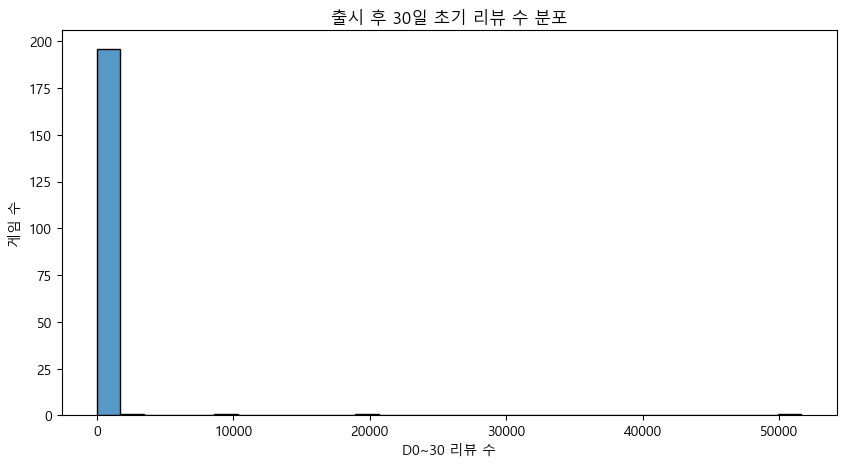

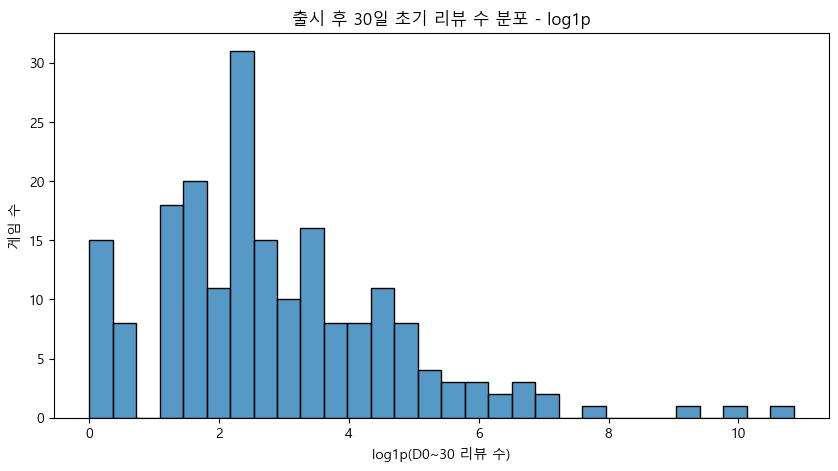

In [59]:
# 원본 분포
plt.figure(figsize=(10, 5))
sns.histplot(
    data=final_reaction_df,
    x="early_reviews_d0_30",
    bins=30
)
plt.title("출시 후 30일 초기 리뷰 수 분포")
plt.xlabel("D0~30 리뷰 수")
plt.ylabel("게임 수")
plt.show()

# 로그 변환 분포
plt.figure(figsize=(10, 5))
sns.histplot(
    x=np.log1p(final_reaction_df["early_reviews_d0_30"]),
    bins=30
)
plt.title("출시 후 30일 초기 리뷰 수 분포 - log1p")
plt.xlabel("log1p(D0~30 리뷰 수)")
plt.ylabel("게임 수")
plt.show()

- 초기 리뷰 수가 높으면 출시 직후 관심을 많이 받은 게임으로 볼 수 있다.
- 다만 리뷰 수 분포가 치우쳐 있으면 평균보다 **중앙값, 분위수, 로그 변환 그래프**를 같이 봐야 한다.
- 이 단계는 "초기 반응 규모"를 보는 것으로, "좋은 반응인지"는 다음 품질 분석에서 따로 확인한다.

# 5. 분석 시작 2: 초기 반응 품질 분석

## 무엇을 보는가

초기 반응 품질은 단순 긍정률만 보면 위험하다.\
리뷰 수가 1~2개인 게임은 긍정률이 쉽게 100%가 될 수 있기 때문이다.

때문에 두 지표를 함께 확인한다.

- `early_positive_ratio_d0_30` :출시 후 30일 단순 긍정률
- `early_wilson_d0_30` :리뷰 수를 고려한 보정 긍정률

In [60]:
quality_summary = final_reaction_df[
    [
        "early_positive_ratio_d0_30",
        "early_wilson_d0_30",
        "post_release_positive_ratio",
        "post_release_wilson"
    ]
].describe().T

display(quality_summary)

print("초기 리뷰 수 10개 이상 기준 Wilson 상위 20개 게임")
top_quality_games = (
    final_reaction_df[final_reaction_df["early_reviews_d0_30"] >= 10]
    .sort_values("early_wilson_d0_30", ascending=False)
    .head(20)
)

display(
    top_quality_games[
        [
            "appid",
            "name",
            "stratum",
            "early_reviews_d0_30",
            "early_positive_ratio_d0_30",
            "early_wilson_d0_30",
            "post_release_reviews_total",
            "post_release_wilson"
        ]
    ]
)


,count,mean,std,min,25%,50%,75%,max
early_positive_ratio_d0_30,185.0,0.847878,0.193300,0.0,0.775510,0.913043,1.000000,1.000000
early_wilson_d0_30,185.0,0.588386,0.236899,0.0,0.438494,0.622635,0.766300,0.984045
post_release_positive_ratio,198.0,0.808627,0.170960,0.0,0.728147,0.855655,0.923537,1.000000
post_release_wilson,198.0,0.654494,0.204848,0.0,0.551964,0.675584,0.809898,0.981248


초기 리뷰 수 10개 이상 기준 Wilson 상위 20개 게임


,appid,name,stratum,early_reviews_d0_30,early_positive_ratio_d0_30,early_wilson_d0_30,post_release_reviews_total,post_release_wilson
29,1671210,DELTARUNE,RPG_high,51634,0.985126,0.984045,93444,0.981248
53,1996010,Crow Country,Action_high,2171,0.986642,0.980882,6932,0.975905
179,3146520,WEBFISHING,Casual_high,19802,0.978184,0.976055,59785,0.974020
125,2585830,Promise Mascot Agency,RPG_high,982,0.981670,0.971212,2379,0.956494
183,3205080,Bad Parenting 1: Mr. Red Face,Adventure_high,1108,0.967509,0.955347,3094,0.885685
182,3198680,Puttler,Sports_mid,148,0.986486,0.952070,234,0.917798
94,2390230,The Chef's Shift,Strategy_high,310,0.964516,0.937587,1534,0.967682
140,2707110,Birds Organized Neatly,Casual_mid,80,0.987500,0.932536,298,0.939340
180,3155430,FIND ALL 5: Vikings,Casual_mid,121,0.975207,0.929634,345,0.915592
95,2393770,"Bang Average Football – Play, Manage, Create",Sports_mid,50,1.000000,0.928650,348,0.933613


## 초기 규모와 품질의 관계

초기 리뷰 수가 많다고 반드시 품질이 좋은 것은 아니기 때문에
아래 그래프는 **초기 반응 규모**와 **Wilson 기준 품질**을 함께 본다.

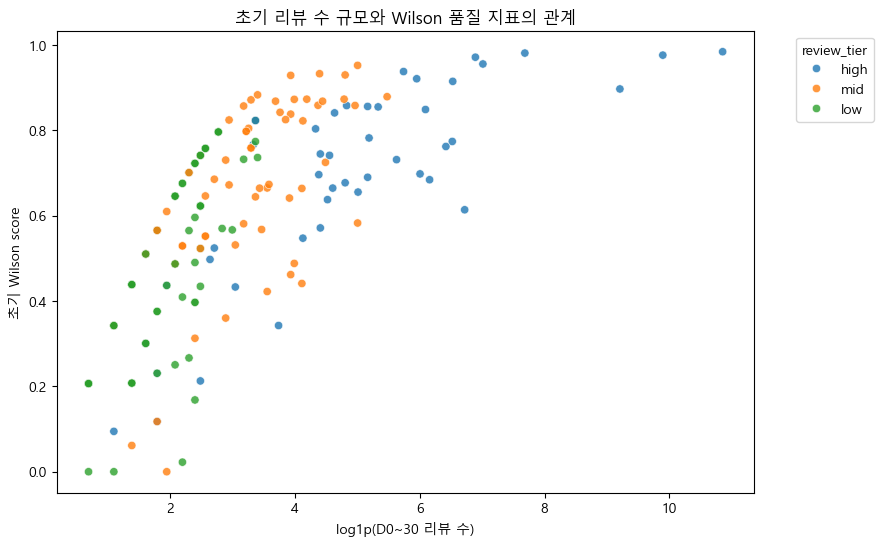

In [61]:
plot_df = final_reaction_df.copy()
plot_df["log_early_reviews"] = np.log1p(plot_df["early_reviews_d0_30"])

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="log_early_reviews",
    y="early_wilson_d0_30",
    hue="review_tier",
    alpha=0.8
)
plt.title("초기 리뷰 수 규모와 Wilson 품질 지표의 관계")
plt.xlabel("log1p(D0~30 리뷰 수)")
plt.ylabel("초기 Wilson score")
plt.legend(title="review_tier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### 해석

- 오른쪽 위: 초기 반응도 크고 품질도 좋은 게임
- 오른쪽 아래: 초기 관심은 받았지만 품질 위험이 있는 게임
- 왼쪽 위: 노출은 작지만 반응 품질이 좋은 게임
- 왼쪽 아래: 초기 반응 규모와 품질이 모두 약한 게임

# 6. 분석 시작 3: 초기 이후 반응 유지력 분석
초기 반응이 좋은 게임이 이후에도 계속 반응을 유지하는지 확인한다.

사용 지표
- later_reviews_d31_180 : 출시 후 31~180일 리뷰 수
- retention_d31_180_vs_d0_30 : 초기 30일 대비 31~180일 리뷰 유지율

In [62]:
retention_summary = final_reaction_df[
    [
        "early_reviews_d0_30",
        "later_reviews_d31_180",
        "retention_d31_90_vs_d0_30",
        "retention_d31_180_vs_d0_30",
        "retention_d181_plus_vs_d0_30"
    ]
].describe().T

display(retention_summary)

print("D31~180 유지율 상위 20개 게임")
top_retention_games = (
    final_reaction_df
    .dropna(subset=["retention_d31_180_vs_d0_30"])
    .sort_values("retention_d31_180_vs_d0_30", ascending=False)
    .head(20)
)

display(
    top_retention_games[
        [
            "appid",
            "name",
            "stratum",
            "early_reviews_d0_30",
            "later_reviews_d31_180",
            "retention_d31_180_vs_d0_30",
            "early_wilson_d0_30"
        ]
    ]
)

,count,mean,std,min,25%,50%,75%,max
early_reviews_d0_30,200.0,480.000000,3960.554603,0.0,4.000000,11.000000,50.000000,51634.000000
later_reviews_d31_180,200.0,432.815000,3265.619485,0.0,3.000000,11.000000,44.750000,33823.000000
retention_d31_90_vs_d0_30,185.0,0.777824,1.252644,0.0,0.105263,0.380000,1.000000,10.951456
retention_d31_180_vs_d0_30,185.0,1.630053,2.979500,0.0,0.264706,0.700000,2.000000,24.000000
retention_d181_plus_vs_d0_30,185.0,2.867787,7.168117,0.0,0.308725,0.833333,3.055556,83.500000


D31~180 유지율 상위 20개 게임


,appid,name,stratum,early_reviews_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30,early_wilson_d0_30
38,1771180,No Fair Play,Sports_high,4,96,24.000000,0.300636
117,2538390,Angry Penguin,Action_mid,8,186,23.250000,0.529105
3,571740,Golf It!,Sports_high,206,2779,13.490291,0.854803
24,1562260,Camping Simulator: The Squad,Simulation_high,11,127,11.545455,0.212710
70,2217580,New Star™ GP,Racing_high,28,321,11.464286,0.822874
61,2141770,URBO,Casual_high,27,165,6.111111,0.766300
78,2276960,a land Goo's crazy,RPG_low,1,6,6.000000,0.206543
118,2539070,I commissioned some bunnies 2,Casual_low,1,6,6.000000,0.206543
63,2153020,Pilfer: Story of Light,Action_mid,2,9,4.500000,0.342372
66,2187230,ALTF42,Racing_high,5,22,4.400000,0.230720


## 초기 리뷰 수와 이후 리뷰 수의 관계
초기 리뷰 수와 이후 리뷰 수가 함께 커지는지 확인한다.\
분포가 심하게 치우쳐 있으므로 `log1p` 변환 후 산점도로 확인

Spearman 상관분석
대상: early_reviews_d0_30 vs later_reviews_d31_180
spearman rho: 0.7127
p-value: 2.553705275291973e-32
n: 200


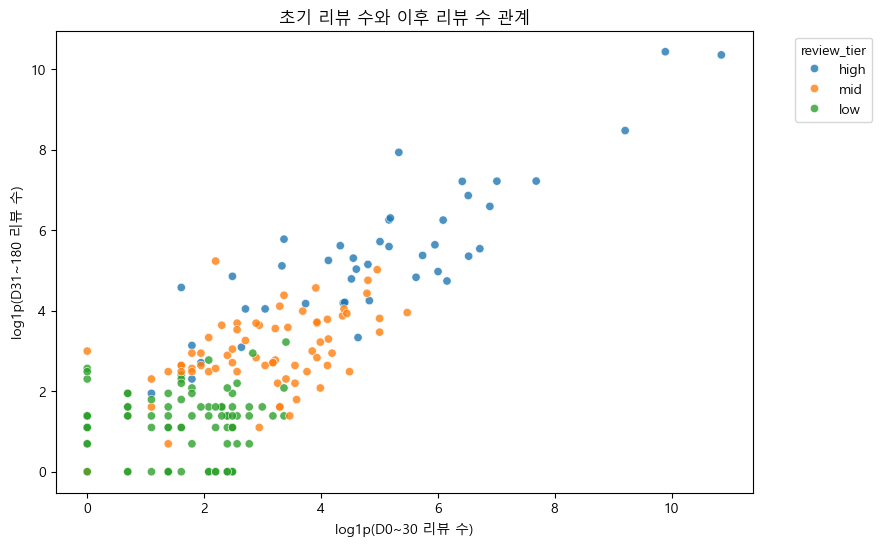

In [63]:
temp_corr = final_reaction_df[
    ["early_reviews_d0_30", "later_reviews_d31_180"]
].dropna()

rho, p_value = spearmanr(
    temp_corr["early_reviews_d0_30"],
    temp_corr["later_reviews_d31_180"]
)

print("Spearman 상관분석")
print("대상: early_reviews_d0_30 vs later_reviews_d31_180")
print("spearman rho:", round(rho, 4))
print("p-value:", p_value)
print("n:", len(temp_corr))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=final_reaction_df,
    x=np.log1p(final_reaction_df["early_reviews_d0_30"]),
    y=np.log1p(final_reaction_df["later_reviews_d31_180"]),
    hue="review_tier",
    alpha=0.8
)
plt.title("초기 리뷰 수와 이후 리뷰 수 관계")
plt.xlabel("log1p(D0~30 리뷰 수)")
plt.ylabel("log1p(D31~180 리뷰 수)")
plt.legend(title="review_tier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


## 해석
- 상관이 높으면 초기 반응 규모가 이후 리뷰 유입과도 이어질 가능성이 있다.
- 상관이 낮으면 초기 반응과 장기 반응은 별개로 봐야 한다.
- 초기 리뷰 수가 적지만 이후 리뷰 수가 큰 게임은 **느린 입소문형 후보**로 볼 수 있다.

# 7. 분석 시작 4: 반응 유형화

## 무엇을 하는가

앞에서 만든 세 가지 축을 기준으로 게임을 유형화
| 축 | 지표 |
|---|---|
| 규모 | `early_reviews_d0_30` |
| 품질 | `early_wilson_d0_30` |
| 유지력 | `retention_d31_180_vs_d0_30` |


분위수 기준으로 **낮음 / 보통 / 높음**을 나눈 뒤, 이를 조합해 반응 유형을 만든다.

In [64]:
valid_early = final_reaction_df[final_reaction_df["early_reviews_d0_30"] > 0].copy()

early_review_q33 = valid_early["early_reviews_d0_30"].quantile(0.33)
early_review_q66 = valid_early["early_reviews_d0_30"].quantile(0.66)

wilson_q33 = valid_early["early_wilson_d0_30"].quantile(0.33)
wilson_q66 = valid_early["early_wilson_d0_30"].quantile(0.66)

retention_q33 = valid_early["retention_d31_180_vs_d0_30"].quantile(0.33)
retention_q66 = valid_early["retention_d31_180_vs_d0_30"].quantile(0.66)

criteria_table = pd.DataFrame({
    "axis": ["초기 규모", "초기 규모", "초기 품질", "초기 품질", "유지력", "유지력"],
    "criteria": ["33% 분위수", "66% 분위수", "33% 분위수", "66% 분위수", "33% 분위수", "66% 분위수"],
    "value": [
        early_review_q33,
        early_review_q66,
        wilson_q33,
        wilson_q66,
        retention_q33,
        retention_q66
    ]
})

display(criteria_table)


def classify_scale(x):
    if pd.isna(x) or x == 0:
        return "반응 없음"
    elif x <= early_review_q33:
        return "낮음"
    elif x <= early_review_q66:
        return "보통"
    else:
        return "높음"


def classify_quality(x):
    if pd.isna(x):
        return "판단 불가"
    elif x <= wilson_q33:
        return "낮음"
    elif x <= wilson_q66:
        return "보통"
    else:
        return "높음"


def classify_retention(x):
    if pd.isna(x):
        return "판단 불가"
    elif x <= retention_q33:
        return "낮음"
    elif x <= retention_q66:
        return "보통"
    else:
        return "높음"


final_reaction_df["early_scale"] = final_reaction_df["early_reviews_d0_30"].apply(classify_scale)
final_reaction_df["early_quality"] = final_reaction_df["early_wilson_d0_30"].apply(classify_quality)
final_reaction_df["reaction_retention"] = final_reaction_df["retention_d31_180_vs_d0_30"].apply(classify_retention)


,axis,criteria,value
0,초기 규모,33% 분위수,8.000000
1,초기 규모,66% 분위수,28.440000
2,초기 품질,33% 분위수,0.510100
3,초기 품질,66% 분위수,0.727207
4,유지력,33% 분위수,0.360927
5,유지력,66% 분위수,1.414738


## 반응 유형 생성

유형은 아래의 의미로 해석한다.

| 유형 | 의미 |
|---|---|
| 초기 흥행형 | 초기 리뷰 수와 품질이 모두 좋고, 이후 유지도 나쁘지 않음 |
| 화제성 불안형 | 초기 리뷰 수는 많지만 품질이 낮음 |
| 초기 관심 후 둔화형 | 초기 리뷰 수는 많지만 이후 유지력이 낮음 |
| 느린 입소문형 | 초기 규모는 작거나 보통이지만 이후 유지력이 높음 |
| 저노출 가능형 | 초기 규모는 작지만 품질은 높음 |
| 품질 위험형 | 품질 지표가 낮음 |
| 일반형 | 위 조건에 명확히 들어가지 않는 게임 |

In [65]:
def classify_reaction_type(row):
    scale = row["early_scale"]
    quality = row["early_quality"]
    retention = row["reaction_retention"]

    if scale == "반응 없음":
        return "초기 반응 없음"

    if scale == "높음" and quality == "높음" and retention in ["보통", "높음"]:
        return "초기 흥행형"

    if scale == "높음" and quality == "낮음":
        return "화제성 불안형"

    if scale == "높음" and retention == "낮음":
        return "초기 관심 후 둔화형"

    if scale in ["낮음", "보통"] and retention == "높음":
        return "느린 입소문형"

    if scale == "낮음" and quality == "높음":
        return "저노출 가능형"

    if quality == "낮음":
        return "품질 위험형"

    return "일반형"


final_reaction_df["reaction_type"] = final_reaction_df.apply(classify_reaction_type, axis=1)

reaction_type_count = (
    final_reaction_df["reaction_type"]
    .value_counts()
    .reset_index()
)

display(reaction_type_count)


,reaction_type,count
0,일반형,52
1,느린 입소문형,50
2,초기 흥행형,32
3,품질 위험형,31
4,초기 관심 후 둔화형,15
5,초기 반응 없음,15
6,화제성 불안형,5


## 요약 그래프

,reaction_type,game_count,early_reviews_median,early_reviews_mean,early_wilson_median,retention_median,later_reviews_median,post_reviews_median
1,일반형,52,15.0,30.480769,0.675584,0.396104,4.0,29.5
0,느린 입소문형,50,5.5,8.480000,0.462680,2.775000,13.5,43.5
4,초기 흥행형,32,133.0,2819.937500,0.858330,0.790000,175.0,606.5
5,품질 위험형,31,4.0,5.483871,0.396773,0.200000,1.0,9.0
2,초기 관심 후 둔화형,15,102.0,223.000000,0.724875,0.261905,27.0,195.0
3,초기 반응 없음,15,0.0,0.000000,NaN,NaN,3.0,9.0
6,화제성 불안형,5,50.0,47.600000,0.441032,0.320000,13.0,79.0


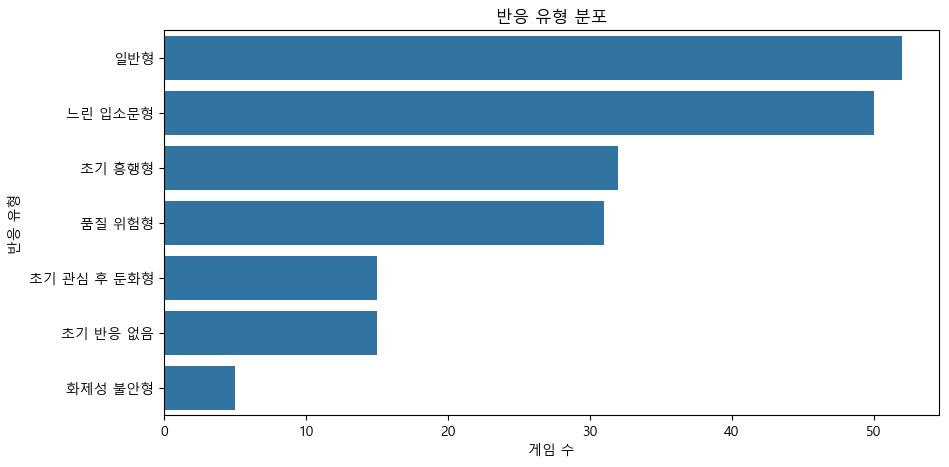

In [66]:
type_summary = (
    final_reaction_df
    .groupby("reaction_type")
    .agg(
        game_count=("appid", "count"),
        early_reviews_median=("early_reviews_d0_30", "median"),
        early_reviews_mean=("early_reviews_d0_30", "mean"),
        early_wilson_median=("early_wilson_d0_30", "median"),
        retention_median=("retention_d31_180_vs_d0_30", "median"),
        later_reviews_median=("later_reviews_d31_180", "median"),
        post_reviews_median=("post_release_reviews_total", "median")
    )
    .reset_index()
    .sort_values("game_count", ascending=False)
)

display(type_summary)

plt.figure(figsize=(10, 5))
order = final_reaction_df["reaction_type"].value_counts().index

sns.countplot(
    data=final_reaction_df,
    y="reaction_type",
    order=order
)
plt.title("반응 유형 분포")
plt.xlabel("게임 수")
plt.ylabel("반응 유형")
plt.show()


## 유형별 핵심 지표 비교

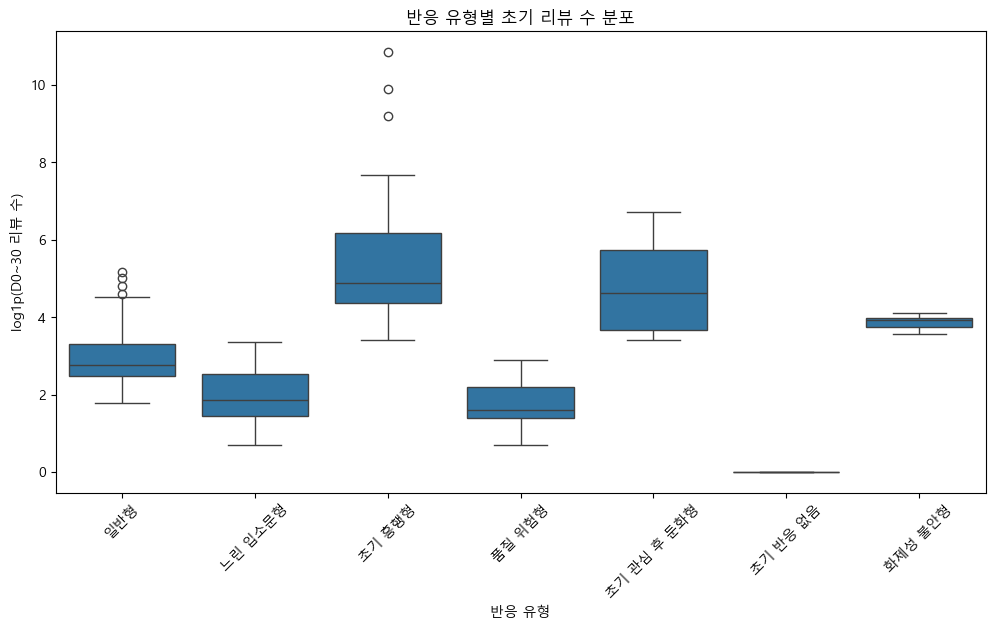

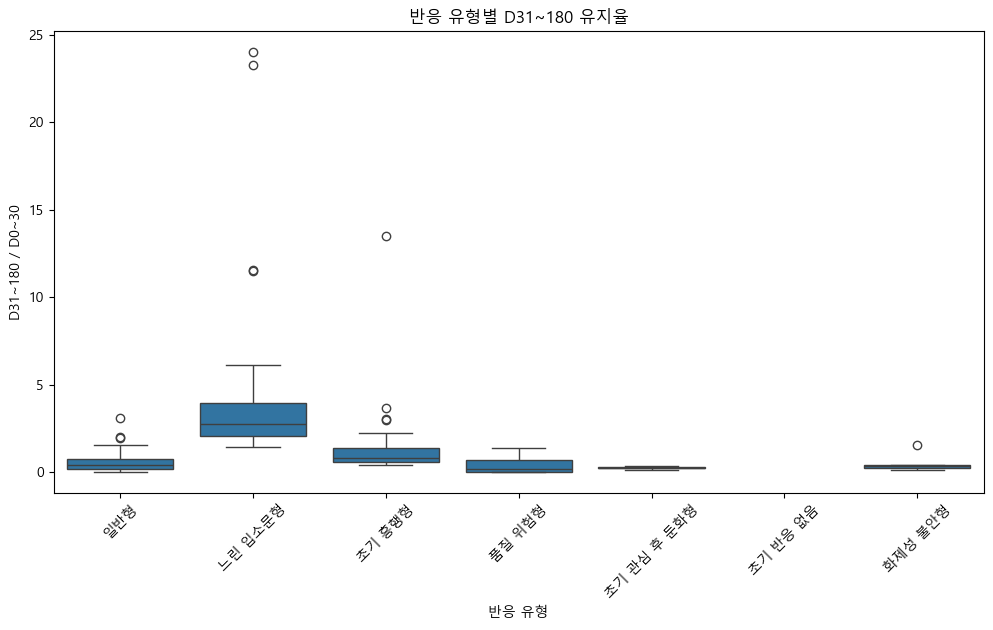

In [67]:
plot_type_df = final_reaction_df.copy()
plot_type_df["log_early_reviews"] = np.log1p(plot_type_df["early_reviews_d0_30"])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_type_df,
    x="reaction_type",
    y="log_early_reviews",
    order=order
)
plt.title("반응 유형별 초기 리뷰 수 분포")
plt.xlabel("반응 유형")
plt.ylabel("log1p(D0~30 리뷰 수)")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=final_reaction_df,
    x="reaction_type",
    y="retention_d31_180_vs_d0_30",
    order=order
)
plt.title("반응 유형별 D31~180 유지율")
plt.xlabel("반응 유형")
plt.ylabel("D31~180 / D0~30")
plt.xticks(rotation=45)
plt.show()


## 유형별 대표 게임 확인

In [68]:
for reaction_type in final_reaction_df["reaction_type"].value_counts().index:
    print("=" * 80)
    print(reaction_type)
    print("=" * 80)

    sample = (
        final_reaction_df[final_reaction_df["reaction_type"] == reaction_type]
        .sort_values(
            ["early_reviews_d0_30", "early_wilson_d0_30", "retention_d31_180_vs_d0_30"],
            ascending=False
        )
        .head(5)
    )

    display(
        sample[
            [
                "appid",
                "name",
                "stratum",
                "early_reviews_d0_30",
                "early_wilson_d0_30",
                "later_reviews_d31_180",
                "retention_d31_180_vs_d0_30"
            ]
        ]
    )


일반형


,appid,name,stratum,early_reviews_d0_30,early_wilson_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30
112,2499800,Garten of Banban 6,Action_high,174,0.689894,267,1.534483
197,3453600,Supercar Collection Simulator,Racing_high,149,0.655226,302,2.026846
65,2185780,Return to abyss 重返深渊,Action_high,121,0.677009,171,1.413223
13,1173220,Bleak Faith: Forsaken,RPG_high,99,0.664570,152,1.535354
7,754890,Firmament,Adventure_high,91,0.637492,119,1.307692


느린 입소문형


,appid,name,stratum,early_reviews_d0_30,early_wilson_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30
70,2217580,New Star™ GP,Racing_high,28,0.822874,321,11.464286
167,2992500,Coin Factory,Strategy_mid,28,0.644082,79,2.821429
61,2141770,URBO,Casual_high,27,0.766300,165,6.111111
86,2329130,Rewind Or Die,Simulation_mid,26,0.758581,60,2.307692
152,2815500,Stardust Demon,Action_mid,24,0.797578,34,1.416667


초기 흥행형


...

,appid,name,stratum,early_reviews_d0_30,early_wilson_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30
124,2581050,KAMITSUBAKI CITY ENSEMBLE,Sports_high,827,0.613732,253,0.305925
5,695330,SEASON: A letter to the future,Casual_high,683,0.914621,210,0.307467
185,3215170,NEEDY STREAMER OVERLOAD: Typing of The Net,Action_high,471,0.684132,113,0.239915
126,2600600,Internet Cafe Evolution,Strategy_high,404,0.697795,143,0.353960
31,1671720,Athenian Rhapsody,RPG_mid,238,0.878688,51,0.214286


초기 반응 없음


,appid,name,stratum,early_reviews_d0_30,early_wilson_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30
39,1789220,Horror haze,Action_low,0,NaN,2,NaN
43,1818590,You Are A Pilot,Racing_mid,0,NaN,0,NaN
46,1840330,Dummy Falls,Action_mid,0,NaN,19,NaN
71,2235530,The Green Room Experiment (Episode 1),Casual_low,0,NaN,3,NaN
74,2254670,Dungeon Cleaner,Strategy_low,0,NaN,2,NaN


화제성 불안형


,appid,name,stratum,early_reviews_d0_30,early_wilson_d0_30,later_reviews_d31_180,retention_d31_180_vs_d0_30
195,3389760,HoloRun,Action_mid,60,0.441032,13,0.216667
159,2864860,Fallen Saint Yhoundeh,RPG_mid,53,0.488067,7,0.132075
54,2015960,Parcel Corps,Racing_mid,50,0.461812,16,0.320000
114,2510130,Auto Sale Life,Simulation_high,41,0.342542,64,1.560976
189,3272110,Mystic Rest Stop,Casual_mid,34,0.422213,13,0.382353


# 8. 보조 분석: 통계 검정과 장르 그룹 비교

## 8-1. 초기 규모 높은 그룹과 낮은 그룹 비교
질문: 초기 리뷰 수가 높은 게임은 이후 31~180일 리뷰 수도 더 많은가?

두 그룹 비교이므로 Mann-Whitney U test를 사용

In [69]:
test_df = final_reaction_df[
    final_reaction_df["early_scale"].isin(["낮음", "높음"])
].dropna(subset=["later_reviews_d31_180"])

low_group = test_df[test_df["early_scale"] == "낮음"]["later_reviews_d31_180"]
high_group = test_df[test_df["early_scale"] == "높음"]["later_reviews_d31_180"]

if len(low_group) > 0 and len(high_group) > 0:
    stat, p_value = mannwhitneyu(
        high_group,
        low_group,
        alternative="two-sided"
    )

    group_test_result = pd.DataFrame({
        "comparison": ["early_scale 높음 vs 낮음"],
        "target": ["later_reviews_d31_180"],
        "low_group_n": [len(low_group)],
        "high_group_n": [len(high_group)],
        "low_group_median": [low_group.median()],
        "high_group_median": [high_group.median()],
        "u_statistic": [stat],
        "p_value": [p_value]
    })

    display(group_test_result)
else:
    print("비교 가능한 그룹 수가 부족합니다.")


,comparison,target,low_group_n,high_group_n,low_group_median,high_group_median,u_statistic,p_value
0,early_scale 높음 vs 낮음,later_reviews_d31_180,63,63,4.0,69.0,3717.0,2.731000e-17


## 8-2. 장르 그룹별 초기 반응 차이

질문: `stratum`에서 분리한 장르 그룹별로 초기 리뷰 수 차이가 있는가?

세 그룹 이상 비교이므로 Kruskal-Wallis test를 사용


,test,target,group_count,groups,h_statistic,p_value
0,Kruskal-Wallis,early_reviews_d0_30,8,"Action, Adventure, Casual, RPG, Racing, Simula...",10.343645,0.169921


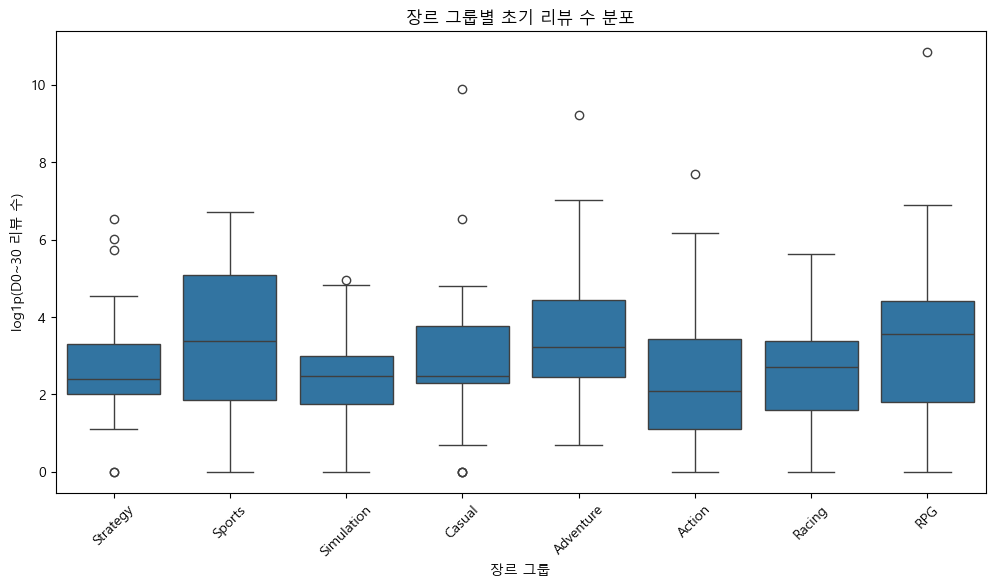

In [70]:
genre_groups = []
genre_names = []

for genre, temp in final_reaction_df.groupby("genre_group"):
    values = temp["early_reviews_d0_30"].dropna()

    if len(values) >= 5:
        genre_groups.append(values)
        genre_names.append(genre)

if len(genre_groups) >= 2:
    stat, p_value = kruskal(*genre_groups)

    genre_test_result = pd.DataFrame({
        "test": ["Kruskal-Wallis"],
        "target": ["early_reviews_d0_30"],
        "group_count": [len(genre_groups)],
        "groups": [", ".join(genre_names)],
        "h_statistic": [stat],
        "p_value": [p_value]
    })

    display(genre_test_result)
else:
    print("검정 가능한 장르 그룹 수가 부족합니다.")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=final_reaction_df,
    x="genre_group",
    y=np.log1p(final_reaction_df["early_reviews_d0_30"])
)
plt.title("장르 그룹별 초기 리뷰 수 분포")
plt.xlabel("장르 그룹")
plt.ylabel("log1p(D0~30 리뷰 수)")
plt.xticks(rotation=45)
plt.show()


## 8-3. 주요 지표 간 Spearman 상관분석


여러 핵심 지표가 서로 어떤 관계를 가지는지 확인한다.\
리뷰 수 분포가 치우쳐 있으므로 Pearson이 아니라 Spearman 상관을 사용

In [71]:
corr_cols = [
    "early_reviews_d0_30",
    "early_wilson_d0_30",
    "mid_reviews_d31_90",
    "long_reviews_d91_180",
    "long_reviews_d181_plus",
    "later_reviews_d31_180",
    "post_release_reviews_total",
    "retention_d31_180_vs_d0_30"
]

corr_df = final_reaction_df[corr_cols].dropna()

corr_results = []

for i, col1 in enumerate(corr_cols):
    for col2 in corr_cols[i + 1:]:
        temp = corr_df[[col1, col2]].dropna()

        if len(temp) >= 3:
            stat, p_value = spearmanr(temp[col1], temp[col2])

            corr_results.append({
                "var1": col1,
                "var2": col2,
                "spearman_r": stat,
                "p_value": p_value,
                "n": len(temp)
            })

corr_result_df = (
    pd.DataFrame(corr_results)
    .sort_values("spearman_r", ascending=False)
)

display(corr_result_df)


,var1,var2,spearman_r,p_value,n
19,long_reviews_d91_180,later_reviews_d31_180,0.969216,2.473980e-113,185
15,mid_reviews_d31_90,later_reviews_d31_180,0.961211,2.631929e-104,185
23,long_reviews_d181_plus,post_release_reviews_total,0.943750,6.947647e-90,185
25,later_reviews_d31_180,post_release_reviews_total,0.943551,9.507535e-90,185
20,long_reviews_d91_180,post_release_reviews_total,0.926607,1.171946e-79,185
16,mid_reviews_d31_90,post_release_reviews_total,0.913590,1.966060e-73,185
22,long_reviews_d181_plus,later_reviews_d31_180,0.910781,3.221533e-72,185
18,long_reviews_d91_180,long_reviews_d181_plus,0.892307,4.064089e-65,185
14,mid_reviews_d31_90,long_reviews_d181_plus,0.880262,3.750064e-61,185
13,mid_reviews_d31_90,long_reviews_d91_180,0.877775,2.185336e-60,185


# 9. 결과 정리

## 9-1. 현 분석으로 말 할 수 있는것
- 출시 후 30일 기준 초기 반응 규모가 큰 게임을 확인할 수 있다.
- 초기 긍정률을 Wilson score로 보정해 더 안정적으로 볼 수 있다.
- 초기 리뷰 수와 이후 리뷰 수의 관계를 볼 수 있다.
- 게임을 `초기 흥행형`, `느린 입소문형`, `품질 위험형` 등으로 분류할 수 있다.
- 이 유형화는 이후 리뷰 본문 분석과 연결할 수 있다.

## 9-2. 이 노트북만으로 말하기 어려운 것
- 왜 부정 리뷰가 나왔는지
- 버그, 최적화, 콘텐츠 부족 등 구체적 원인
- 패치 우선순위
- 가격대/태그/장르의 정확한 영향

> 이 부분은 `steam_indie_reviews`, `steam_indie_games`, `steam_indie_tags`와 연결해 추가 분석 필요
